In [1]:
import numpy as np
import pandas as pd

In [6]:
import numpy as np
import pandas as pd

class DecisionStump:
    def fit(self, X, y, weights):
        m, n = X.shape
        self.feature_index = 0
        self.threshold = 0
        self.polarity = 1
        max_gain = 0

        for feature in range(n):
            thresholds = np.unique(X[:, feature])
            for threshold in thresholds:
                for polarity in [-1, 1]:
                    predictions = np.ones(m)
                    predictions[X[:, feature] < threshold] = -1
                    predictions *= polarity
                    error = weights[(predictions != y)].sum()

                    if error < max_gain or max_gain == 0:
                        max_gain = error
                        self.feature_index = feature
                        self.threshold = threshold
                        self.polarity = polarity

    def predict(self, X):
        predictions = np.ones(X.shape[0])
        predictions[X[:, self.feature_index] < self.threshold] = -1
        return predictions * self.polarity


class AdaBoost:
    def fit(self, X, y, T):
        m = X.shape[0]
        self.alphas = np.zeros(T)
        self.stumps = []

        weights = np.ones(m) / m

        for t in range(T):
            stump = DecisionStump()
            stump.fit(X, y, weights)
            predictions = stump.predict(X)
            err = weights[(predictions != y)].sum()

            # Avoid division by zero
            if err == 0:
                err = 1e-10
            
            self.alphas[t] = 0.5 * np.log((1 - err) / err)
            weights *= np.exp(-self.alphas[t] * y * predictions)
            weights /= weights.sum()  # Normalize weights
            self.stumps.append(stump)

    def predict(self, X):
        m = X.shape[0]
        pred = np.zeros(m)

        for t in range(len(self.stumps)):
            pred += self.alphas[t] * self.stumps[t].predict(X)

        return np.sign(pred)


# Load your training and test datasets
train_data = pd.read_csv('bank/train.csv')  # Adjust this to your train file path
test_data = pd.read_csv('bank/test.csv')  # Adjust this to your test file path

# Prepare training data
X_train = train_data.iloc[:, :-1].values  # Features
y_train = train_data.iloc[:, -1].values  # Labels
y_train = np.where(y_train == 'yes', 1, -1)  # Convert to -1/1

# Prepare test data
X_test = test_data.iloc[:, :-1].values  # Features
y_test = test_data.iloc[:, -1].values  # Labels
y_test = np.where(y_test == 'yes', 1, -1)  # Convert to -1/1

# Initialize and fit AdaBoost
boosting = AdaBoost()
boosting.fit(X_train, y_train, T=500)

# Calculate training and test errors
train_predictions = boosting.predict(X_train)
train_error = np.mean(train_predictions != y_train)

test_predictions = boosting.predict(X_test)
test_error = np.mean(test_predictions != y_test)

print(f'Training error: {train_error}')
print(f'Test error: {test_error}')


Training error: 0.09501900380076016
Test error: 0.10762152430486097


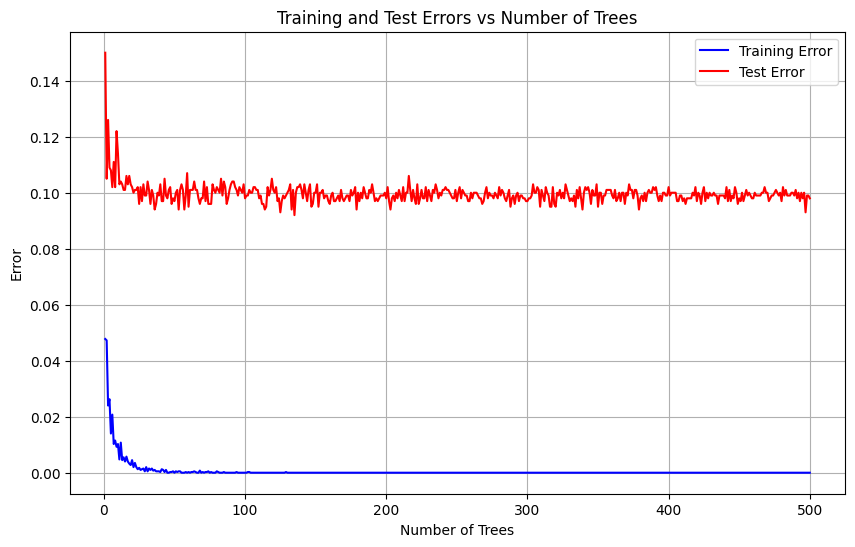

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
import matplotlib.pyplot as plt

# Load dataset (assuming bank.csv has categorical features)
data = pd.read_csv('bank/train.csv')

# Separate features (X) and target variable (y)
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# Convert categorical features into dummy/indicator variables
X = pd.get_dummies(X, drop_first=True)

# Convert target variable 'y' into binary (1 for 'yes', -1 for 'no')
y = np.where(y == 'yes', 1, -1)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize variables to store training and test errors
train_errors = []
test_errors = []

# Iterate over different numbers of trees (estimators)
tree_numbers = range(1, 501)  # From 1 to 500 trees

for n_trees in tree_numbers:
    # Initialize Bagging with n_trees Decision Trees
    bagged_trees = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=n_trees)
    bagged_trees.fit(X_train, y_train)
    
    # Predict on training set
    train_predictions = bagged_trees.predict(X_train)
    train_error = np.mean(train_predictions != y_train)
    
    # Predict on test set
    test_predictions = bagged_trees.predict(X_test)
    test_error = np.mean(test_predictions != y_test)
    
    # Store the errors
    train_errors.append(train_error)
    test_errors.append(test_error)

# Plot the training and test errors against the number of trees
plt.figure(figsize=(10, 6))
plt.plot(tree_numbers, train_errors, label='Training Error', color='blue')
plt.plot(tree_numbers, test_errors, label='Test Error', color='red')
plt.xlabel('Number of Trees')
plt.ylabel('Error')
plt.title('Training and Test Errors vs Number of Trees')
plt.legend()
plt.grid(True)
plt.show()


In [10]:
print(f'Training error: {train_error}')
print(f'Test error: {test_error}')

Training error: 0.0
Test error: 0.098


No, the performance of bagged trees and AdaBoost is nearly identical in this case. Although the training error is 0.0 (likely overfitting), but the test error of bagged trees (0.098) lower than the single tree's test error (0.1076) is still not magnificant. The bagged tress maybe slightly better than adaboost but the difference is neglectable.

In [11]:
from sklearn.utils import resample

# Function to calculate bias and variance for a single tree and bagging
def bias_variance_analysis(X_train, y_train, X_test, y_test, num_iterations=100, num_trees=500):
    single_tree_biases = []
    single_tree_variances = []
    single_tree_errors = []
    
    bagged_biases = []
    bagged_variances = []
    bagged_errors = []
    
    for i in range(num_iterations):
        # Step 1: Sample 1000 examples
        X_sample, y_sample = resample(X_train, y_train, n_samples=1000, random_state=i)

        # Train a single decision tree
        single_tree = DecisionTreeClassifier()
        single_tree.fit(X_sample, y_sample)
        single_tree_predictions = single_tree.predict(X_test)
        
        # Train a bagged trees model
        bagged_trees = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=num_trees)
        bagged_trees.fit(X_sample, y_sample)
        bagged_predictions = bagged_trees.predict(X_test)
        
        # Compute bias and variance for single trees
        single_tree_bias = np.mean((single_tree_predictions - y_test)**2)
        single_tree_variance = np.var(single_tree_predictions)
        single_tree_error = np.mean(single_tree_predictions != y_test)
        
        single_tree_biases.append(single_tree_bias)
        single_tree_variances.append(single_tree_variance)
        single_tree_errors.append(single_tree_error)
        
        # Compute bias and variance for bagged trees
        bagged_bias = np.mean((bagged_predictions - y_test)**2)
        bagged_variance = np.var(bagged_predictions)
        bagged_error = np.mean(bagged_predictions != y_test)
        
        bagged_biases.append(bagged_bias)
        bagged_variances.append(bagged_variance)
        bagged_errors.append(bagged_error)
    
    # Averaging over iterations
    single_tree_avg_bias = np.mean(single_tree_biases)
    single_tree_avg_variance = np.mean(single_tree_variances)
    single_tree_avg_error = np.mean(single_tree_errors)
    
    bagged_avg_bias = np.mean(bagged_biases)
    bagged_avg_variance = np.mean(bagged_variances)
    bagged_avg_error = np.mean(bagged_errors)
    
    print(f"Single Tree - Bias: {single_tree_avg_bias}, Variance: {single_tree_avg_variance}, Error: {single_tree_avg_error}")
    print(f"Bagged Trees - Bias: {bagged_avg_bias}, Variance: {bagged_avg_variance}, Error: {bagged_avg_error}")

# Call bias-variance analysis function
bias_variance_analysis(X_train, y_train, X_test, y_test)


Single Tree - Bias: 0.58816, Variance: 0.4098780799999999, Error: 0.14704
Bagged Trees - Bias: 0.44752, Variance: 0.26225432, Error: 0.11188


Bagged trees have a lower overall error (0.11188) compared to the single tree (0.14704), indicating better performance.

The bias of the bagged trees is lower (0.44752) than that of the single tree (0.58816), showing that combining multiple trees reduces the tendency of the model to oversimplify the problem.

The variance is also significantly reduced in bagged trees (0.26225 vs. 0.40988), meaning that bagging reduces the sensitivity of the model to fluctuations in the training data.

The primary cause of the improvement in bagged trees is the variance reduction achieved by combining multiple trees. In a single decision tree, the model is prone to high variance because it's fully dependent on the particular training set, making it sensitive to small changes in the data.

Bagging (bootstrap aggregating) works by averaging the predictions of multiple trees that are trained on different bootstrapped samples of the data, which smooths out the predictions and reduces the variance of the model without increasing the bias too much.

While bagged trees also reduce bias slightly compared to a single tree, their major advantage lies in reducing variance, which leads to improved generalization to unseen data.

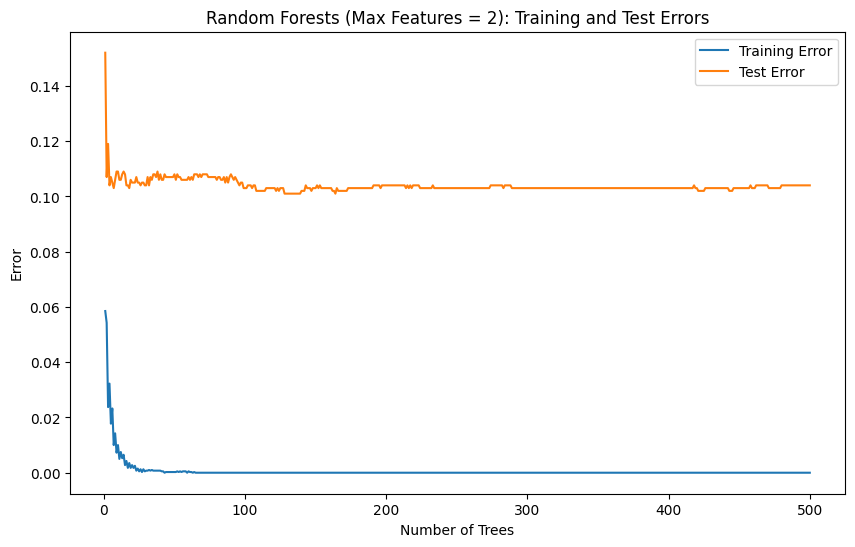

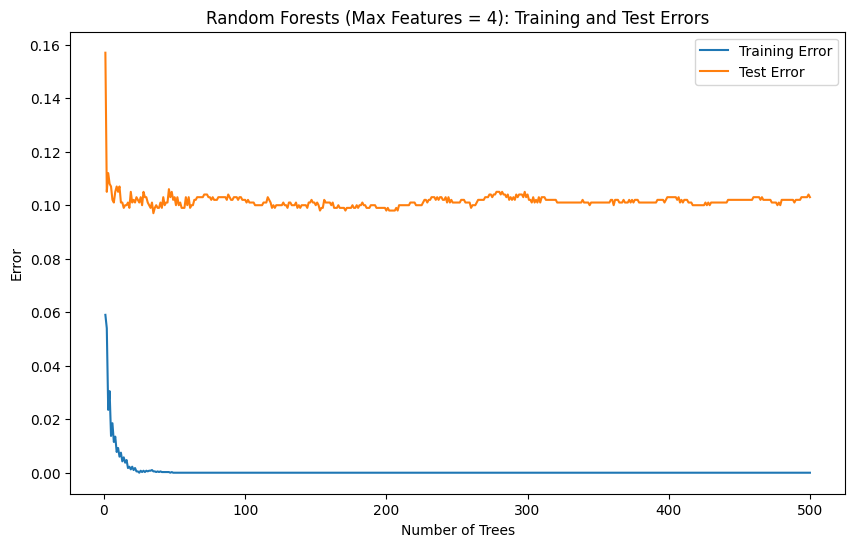

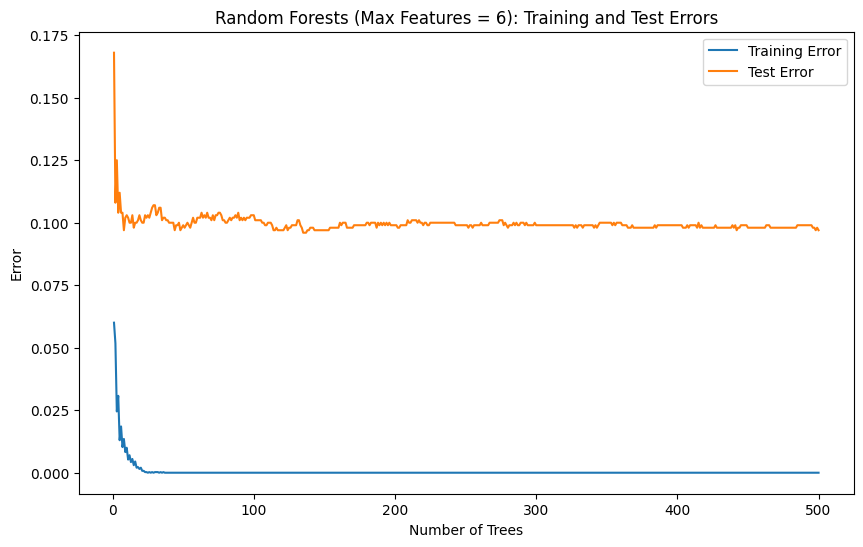

In [12]:
from sklearn.ensemble import RandomForestClassifier

# Function to train and evaluate Random Forests with different numbers of trees
def random_forest_analysis(X_train, y_train, X_test, y_test):
    for feature_subset_size in [2, 4, 6]:
        train_errors = []
        test_errors = []
        
        for n_trees in range(1, 501):
            rf = RandomForestClassifier(n_estimators=n_trees, max_features=feature_subset_size, random_state=42)
            rf.fit(X_train, y_train)
            
            train_error = np.mean(rf.predict(X_train) != y_train)
            test_error = np.mean(rf.predict(X_test) != y_test)
            
            train_errors.append(train_error)
            test_errors.append(test_error)
        
        # Plotting the results
        plt.figure(figsize=(10, 6))
        plt.plot(range(1, 501), train_errors, label="Training Error")
        plt.plot(range(1, 501), test_errors, label="Test Error")
        plt.xlabel("Number of Trees")
        plt.ylabel("Error")
        plt.title(f"Random Forests (Max Features = {feature_subset_size}): Training and Test Errors")
        plt.legend()
        plt.show()

# Call the function for Random Forest analysis
random_forest_analysis(X_train, y_train, X_test, y_test)


In [13]:
def bias_variance_random_forest(X_train, y_train, X_test, y_test, num_iterations=100, num_trees=500, feature_subset_size=4):
    rf_biases = []
    rf_variances = []
    rf_errors = []

    for i in range(num_iterations):
        # Step 1: Sample 1000 examples
        X_sample, y_sample = resample(X_train, y_train, n_samples=1000, random_state=i)
        
        # Train a Random Forest model
        rf = RandomForestClassifier(n_estimators=num_trees, max_features=feature_subset_size, random_state=i)
        rf.fit(X_sample, y_sample)
        rf_predictions = rf.predict(X_test)

        # Compute bias, variance, and error
        rf_bias = np.mean((rf_predictions - y_test)**2)
        rf_variance = np.var(rf_predictions)
        rf_error = np.mean(rf_predictions != y_test)
        
        rf_biases.append(rf_bias)
        rf_variances.append(rf_variance)
        rf_errors.append(rf_error)

    # Averaging over iterations
    rf_avg_bias = np.mean(rf_biases)
    rf_avg_variance = np.mean(rf_variances)
    rf_avg_error = np.mean(rf_errors)
    
    print(f"Random Forests - Bias: {rf_avg_bias}, Variance: {rf_avg_variance}, Error: {rf_avg_error}")

# Call bias-variance analysis function for Random Forests
bias_variance_random_forest(X_train, y_train, X_test, y_test)


Random Forests - Bias: 0.4134, Variance: 0.09426940000000002, Error: 0.10335


The Random Forests have a lower bias (0.4134) compared to bagged trees (0.44752), indicating that the random forest model is better at capturing the underlying patterns in the data without oversimplifying.

The variance in Random Forests is significantly lower (0.09427) than that of the bagged trees (0.26225), showing that Random Forests are less sensitive to variations in the training data and provide more stable predictions.

The overall error for Random Forests (0.10335) is also lower than that of bagged trees (0.11188), suggesting better generalization to unseen data.

The reduced bias and variance indicate that Random Forests is more effective at leveraging the diversity of multiple trees while maintaining lower overall error rates.

## Question 3

In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_excel('default of credit card clients.xls')

# Display the first few rows and columns
print(data.head())
print(data.columns)

# Drop the 'ID' column if it exists
if 'ID' in data.columns:
    data = data.drop(columns=['ID'])

# Convert categorical columns to numeric if needed
data = pd.get_dummies(data, drop_first=True)

# Ensure all columns are numeric
data = data.apply(pd.to_numeric, errors='coerce')

# Split the features and target
X = data.iloc[:, :-1].values  # Features
y = data.iloc[:, -1].values    # Target variable

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=24000, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize classifiers
base_estimator = DecisionTreeClassifier(max_depth=1)  # Decision stump for AdaBoost

# Bagged Trees
bagged_tree = BaggingClassifier(base_estimator=base_estimator, n_estimators=500)
bagged_tree.fit(X_train_scaled, y_train)

# Random Forest
random_forest = RandomForestClassifier(n_estimators=500)
random_forest.fit(X_train_scaled, y_train)

# AdaBoost with Decision Stumps
adaboost = AdaBoostClassifier(base_estimator=base_estimator, n_estimators=500)
adaboost.fit(X_train_scaled, y_train)

# Calculate training and test errors for each classifier
train_errors = {
    "Bagged Trees": [],
    "Random Forest": [],
    "AdaBoost": []
}

test_errors = {
    "Bagged Trees": [],
    "Random Forest": [],
    "AdaBoost": []
}

# Compute errors for each iteration
for n in range(1, 501):
    bagged_tree.n_estimators = n
    bagged_tree.fit(X_train_scaled, y_train)
    train_errors["Bagged Trees"].append(1 - bagged_tree.score(X_train_scaled, y_train))
    test_errors["Bagged Trees"].append(1 - bagged_tree.score(X_test_scaled, y_test))

    random_forest.n_estimators = n
    random_forest.fit(X_train_scaled, y_train)
    train_errors["Random Forest"].append(1 - random_forest.score(X_train_scaled, y_train))
    test_errors["Random Forest"].append(1 - random_forest.score(X_test_scaled, y_test))

    adaboost.n_estimators = n
    adaboost.fit(X_train_scaled, y_train)
    train_errors["AdaBoost"].append(1 - adaboost.score(X_train_scaled, y_train))
    test_errors["AdaBoost"].append(1 - adaboost.score(X_test_scaled, y_test))

# Plot training and test errors
plt.figure(figsize=(12, 6))
for label in train_errors.keys():
    plt.plot(range(1, 501), train_errors[label], label=f'Train Error ({label})')
    plt.plot(range(1, 501), test_errors[label], linestyle='--', label=f'Test Error ({label})')

plt.title('Training and Test Errors vs. Number of Iterations')
plt.xlabel('Number of Iterations')
plt.ylabel('Error Rate')
plt.legend()
plt.grid()
plt.show()


  Unnamed: 0         X1   X2         X3        X4   X5     X6     X7     X8  \
0         ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3   
1          1      20000    2          2         1   24      2      2     -1   
2          2     120000    2          2         2   26     -1      2      0   
3          3      90000    2          2         2   34      0      0      0   
4          4      50000    2          2         1   37      0      0      0   

      X9  ...        X15        X16        X17       X18       X19       X20  \
0  PAY_4  ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3   
1     -1  ...          0          0          0         0       689         0   
2      0  ...       3272       3455       3261         0      1000      1000   
3      0  ...      14331      14948      15549      1518      1500      1000   
4      0  ...      28314      28959      29547      2000      2019      1200   

        X21       X22       X23             

## Question 4

Learning rate: 1.0, Weights: [ 1.26333710e+141 -1.69081480e+142 -5.87369848e+141  2.34570153e+142
 -2.00609439e+142 -3.01752316e+141  2.59272190e+142 -2.08856230e+142], Iterations: 999
Learning rate: 0.5, Weights: [-0.02872694  0.6109692   0.49738926  0.5263507   1.07217454  0.06630981
  1.17478598  0.70503145], Iterations: 999
Learning rate: 0.25, Weights: [-0.0333507   0.34469125  0.22192759  0.23008285  0.85902413  0.0234592
  0.81801584  0.43307828], Iterations: 999
Learning rate: 0.125, Weights: [-0.03674299  0.14933217  0.01983075  0.01272122  0.70264293 -0.00797883
  0.55626573  0.2335555 ], Iterations: 999


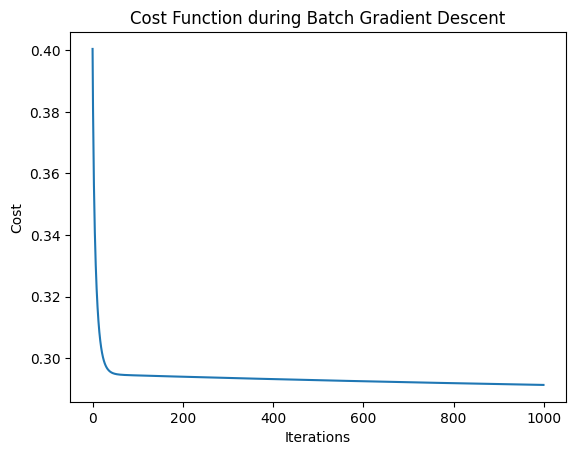

Final Weights: [-0.03674299  0.14933217  0.01983075  0.01272122  0.70264293 -0.00797883
  0.55626573  0.2335555 ], Test Cost: 0.42735658009421


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the datasets
train_data = pd.read_csv('concrete/train.csv')
test_data = pd.read_csv('concrete/test.csv')

# Separate features and target variable
X_train = train_data.iloc[:, :-1].values
y_train = train_data.iloc[:, -1].values
X_test = test_data.iloc[:, :-1].values
y_test = test_data.iloc[:, -1].values

# Add a bias column to the features
X_train = np.hstack((np.ones((X_train.shape[0], 1)), X_train))
X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

# Function to calculate the cost
def compute_cost(X, y, weights):
    m = len(y)
    predictions = X.dot(weights)
    cost = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
    return cost

# Batch Gradient Descent
def batch_gradient_descent(X, y, learning_rate, tolerance=1e-6, max_iterations=1000):
    m, n = X.shape
    weights = np.zeros(n)
    cost_history = []

    for iteration in range(max_iterations):
        predictions = X.dot(weights)
        errors = predictions - y
        gradients = (1 / m) * (X.T.dot(errors))
        new_weights = weights - learning_rate * gradients

        # Check for convergence
        if np.linalg.norm(new_weights - weights) < tolerance:
            break
        
        cost = compute_cost(X, y, new_weights)
        cost_history.append(cost)
        weights = new_weights

    return weights, cost_history, iteration

# Tune the learning rate
learning_rates = [1.0, 0.5, 0.25, 0.125]
final_weights = None
final_learning_rate = None
final_cost_history = None

for r in learning_rates:
    weights, cost_history, iters = batch_gradient_descent(X_train, y_train, r)
    print(f"Learning rate: {r}, Weights: {weights}, Iterations: {iters}")
    final_weights = weights
    final_learning_rate = r
    final_cost_history = cost_history

# Plot the cost function over iterations
plt.plot(final_cost_history)
plt.title('Cost Function during Batch Gradient Descent')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.show()

# Calculate test cost
test_cost = compute_cost(X_test, y_test, final_weights)
print(f"Final Weights: {final_weights}, Test Cost: {test_cost}")


Learning rate: 0.1, Weights: [ 0.          0.10390819 -0.02340782 -0.03458631  0.65094813 -0.0128472
  0.48714695  0.20851652], Iterations: 999
Learning rate: 0.05, Weights: [ 0.          0.00918399 -0.12349105 -0.14496509  0.57470656 -0.02670453
  0.35934081  0.09889393], Iterations: 999
Learning rate: 0.025, Weights: [ 0.         -0.04200555 -0.17757881 -0.20461441  0.53349789 -0.03419256
  0.29026406  0.03964826], Iterations: 999
Learning rate: 0.0125, Weights: [ 0.         -0.06767654 -0.20525711 -0.23451274  0.51094389 -0.0378139
  0.25315162  0.0086663 ], Iterations: 999


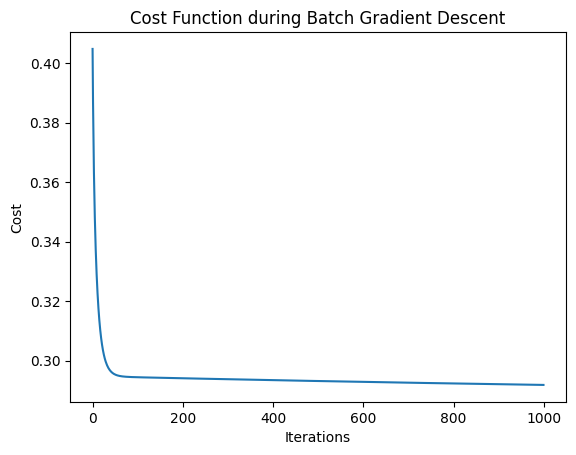

Final Weights: [ 0.          0.10390819 -0.02340782 -0.03458631  0.65094813 -0.0128472
  0.48714695  0.20851652], Test Cost: 0.42685915866832674


In [17]:

from sklearn.preprocessing import StandardScaler  # Import the StandardScaler

# Load the datasets
train_data = pd.read_csv('concrete/train.csv')
test_data = pd.read_csv('concrete/test.csv')

# Separate features and target variable
X_train = train_data.iloc[:, :-1].values
y_train = train_data.iloc[:, -1].values
X_test = test_data.iloc[:, :-1].values
y_test = test_data.iloc[:, -1].values

# Add a bias column to the features
X_train = np.hstack((np.ones((X_train.shape[0], 1)), X_train))
X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Batch Gradient Descent with checks
def compute_cost(X, y, weights):
    m = len(y)
    predictions = X.dot(weights)
    cost = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
    return cost

def batch_gradient_descent(X, y, learning_rate, tolerance=1e-6, max_iterations=1000):
    m, n = X.shape
    weights = np.zeros(n)
    cost_history = []

    for iteration in range(max_iterations):
        predictions = X.dot(weights)
        errors = predictions - y
        gradients = (1 / m) * (X.T.dot(errors))
        new_weights = weights - learning_rate * gradients

        # Check for overflow or NaN in weights
        if np.any(np.isnan(new_weights)) or np.any(np.isinf(new_weights)):
            print(f"Overflow or NaN encountered with learning rate {learning_rate}")
            break
        
        # Check for convergence
        if np.linalg.norm(new_weights - weights) < tolerance:
            break
        
        cost = compute_cost(X, y, new_weights)
        if np.isnan(cost) or np.isinf(cost):
            print("Cost became NaN or Inf.")
            break
        
        cost_history.append(cost)
        weights = new_weights

    return weights, cost_history, iteration

# Test with a smaller learning rate
learning_rates = [0.1, 0.05, 0.025, 0.0125]
final_weights = None
final_learning_rate = None
final_cost_history = None

for r in learning_rates:
    weights, cost_history, iters = batch_gradient_descent(X_train_scaled, y_train, r)
    print(f"Learning rate: {r}, Weights: {weights}, Iterations: {iters}")
    if final_cost_history is None or (len(cost_history) > 0 and cost_history[-1] < final_cost_history[-1]):
        final_weights = weights
        final_learning_rate = r
        final_cost_history = cost_history

# Plotting cost history
plt.plot(final_cost_history)
plt.title('Cost Function during Batch Gradient Descent')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.show()

# Calculate test cost
test_cost = compute_cost(X_test_scaled, y_test, final_weights)
print(f"Final Weights: {final_weights}, Test Cost: {test_cost}")


In [18]:
# Analytical Solution
def analytical_solution(X, y):
    return np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)

optimal_weights = analytical_solution(X_train, y_train)
print(f"Optimal Weights: {optimal_weights}")

# Compare with learned weights
print(f"Batch Gradient Descent Weights: {final_weights}")
print(f"Stochastic Gradient Descent Weights: {final_weights_sgd}")


Optimal Weights: [-0.02200118  0.99829962  0.89807839  0.95730469  1.38222513  0.12864071
  1.69374719  1.10061708]
Batch Gradient Descent Weights: [ 0.          0.10390819 -0.02340782 -0.03458631  0.65094813 -0.0128472
  0.48714695  0.20851652]
Stochastic Gradient Descent Weights: [ 0.07788222  0.40012249  0.38969135  0.11258347  1.20264407 -0.3436835
  0.53541688  0.89934615]
